['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']
                                            filename  width  height  \
0  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
1  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
2  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
3  c--188-_jpg.rf.df8c04f880e507f44d63d74b701f381...    563     537   
4  f--28-_jpg.rf.de4fc5ebba3bbc0baea64e669225c7c5...    563     537   

          class  xmin  ymin  xmax  ymax  
0  Microplastic   271    15   305    46  
1  Microplastic   348   265   402   308  
2  Microplastic   146   279   181   317  
3  Microplastic   477   302   542   367  
4  Microplastic   279   137   337   205  
      filename  width  height  class   xmin   ymin   xmax   ymax
0        False  False   False  False  False  False  False  False
1        False  False   False  False  False  False  False  False
2        False  False   False  False  False  False  F

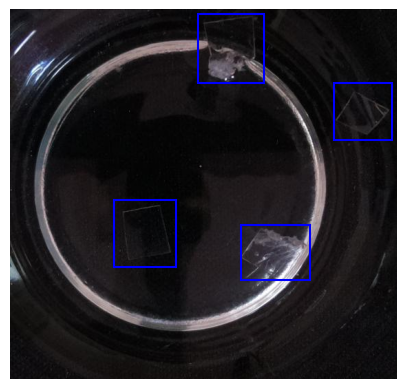

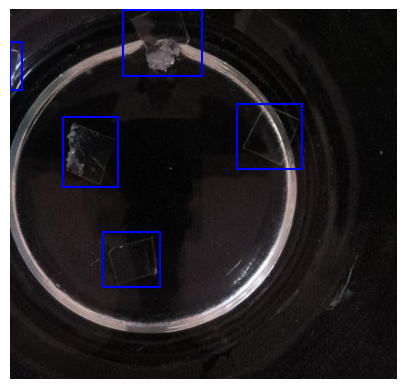

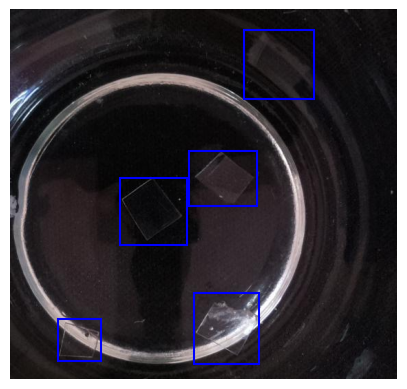

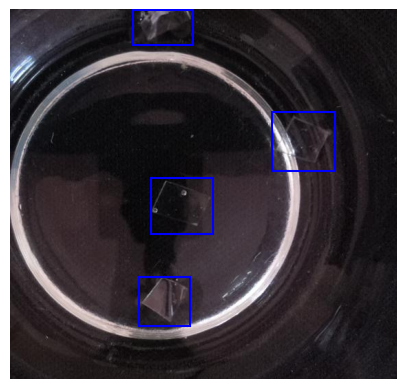

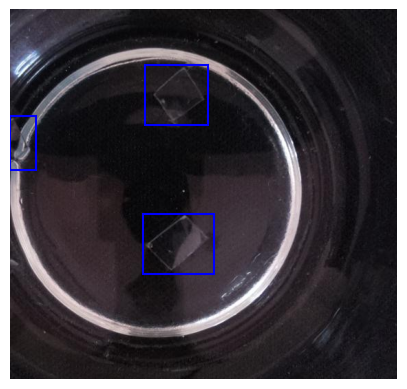

Split 781 images -> train:546 valid:156 test:79


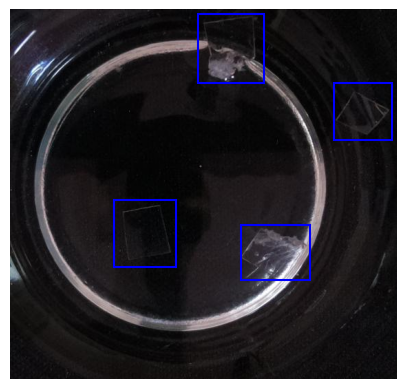

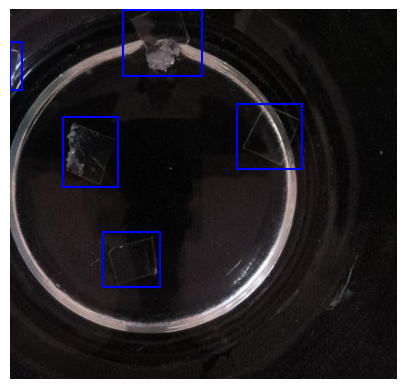

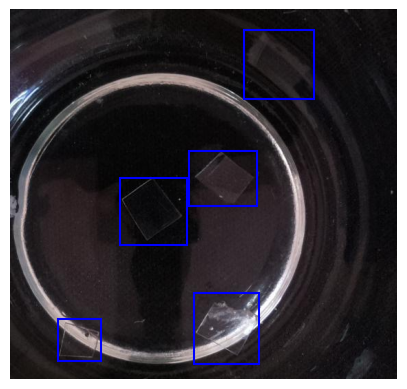

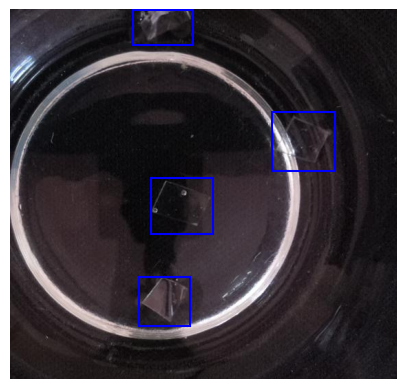

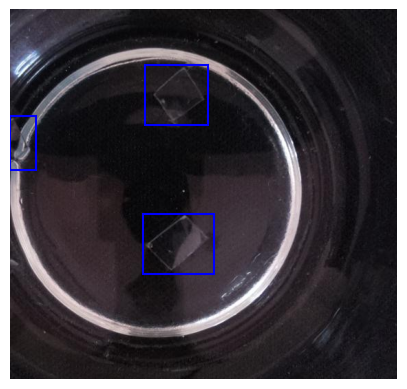

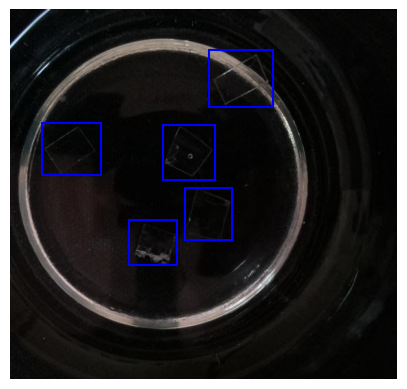

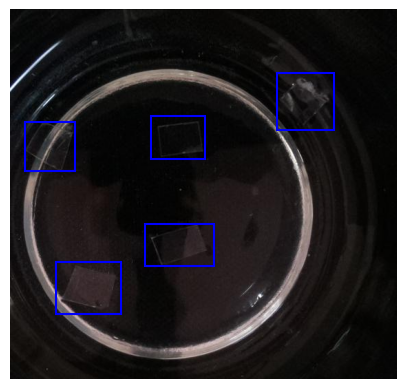

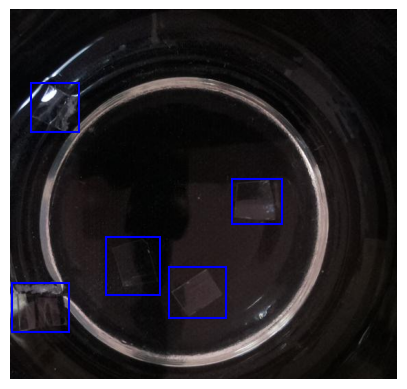

In [3]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

sys.path.append("../src")

CSV_PATH = "../data/microplastic-dataset-for-computer-vision/_annotations.csv"
IMAGES_DIR = "../data/microplastic-dataset-for-computer-vision"

df = pd.read_csv(CSV_PATH)
print(df.columns.tolist())
print(df.head())
print(df.isna())
print(df[df.duplicated()])

from data_loader import convert_csv_to_yolo, draw_boxes, split_dataset

class_names = convert_csv_to_yolo(
    csv_path="../data/microplastic-dataset-for-computer-vision/_annotations.csv",
    images_dir="../data/microplastic-dataset-for-computer-vision",
    labels_out_dir="../data/microplastic-dataset-for-computer-vision/labels"
)

# sanity check a few images
import os
label_dir = "../data/microplastic-dataset-for-computer-vision/labels"
sample_images = [f for f in os.listdir("../data/microplastic-dataset-for-computer-vision") if f.endswith(".jpg")]
labelled_images = [f for f in sample_images if os.path.exists(os.path.join(label_dir, f.replace('.jpg', '.txt')))]
for img_name in labelled_images[:5]:
    img_path = f"../data/microplastic-dataset-for-computer-vision/{img_name}"
    label_path = f"{label_dir}/{img_name.replace('.jpg', '.txt')}"
    draw_boxes(img_path, label_path)

split_dataset(
    images_dir="../data/microplastic-dataset-for-computer-vision",
    labels_dir="../data/microplastic-dataset-for-computer-vision/labels",
    output_dir="../data/microplastic-dataset-for-computer-vision"
)

import os
from data_loader import draw_boxes

base_dir = "../data/microplastic-dataset-for-computer-vision"
label_dir = os.path.join(base_dir, "labels")
sample_images = [f for f in os.listdir(base_dir) if f.endswith(".jpg")]
labelled_images = [f for f in sample_images if os.path.exists(os.path.join(label_dir, f.replace('.jpg', '.txt')))]

for img_name in labelled_images[:8]:
    img_path = os.path.join(base_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))
    draw_boxes(img_path, label_path)


In [ ]:

# import sys
# sys.path.append("src")
# from train import run_quick_test
# run_quick_test()

